In [1]:
# Imports
from google.colab import drive
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Remove limit for diplaying columns
pd.set_option('display.max_colwidth', None)

In [3]:
# Mount drive, if needed
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
# Path to Google Drive project directory
drive_project_dir = '/content/drive/MyDrive/twitter-multimodal-hate-speech-classifier'

# Set project directory as current working directory
os.chdir(drive_project_dir)

# Set path to directory for data files in Google Drive
drive_data_dir = 'data' # relative path
os.makedirs(drive_data_dir, exist_ok=True)

# Set path to directory for reports (plots, tables) in Google Drive
drive_reports_dir = 'reports' # relative path
os.makedirs(drive_reports_dir, exist_ok=True)

# Path to raw data .zip file
zip_path = os.path.join(drive_data_dir, 'multimodal-hate-speech.zip')

In [5]:
# Import functions from utils
from src.data_utils import get_majority_vote, plot_tweet_length_distribution, plot_tweet_volume_over_time, plot_hate_speech_proportions
from src.load_utils import load_split_ids

In [6]:
# Load whole dataset from existing parquet
data = pd.read_parquet(os.path.join(drive_data_dir, 'twitter_data_with_img_caption.parquet'))

In [7]:
# Define mapping: int labels into str
labels_dict = {0: 'NotHate', 1: 'Racist', 2: 'Sexist', 3: 'Homophobe', 4: 'Religion', 5: 'OtherHate'}

## 1.Опис набору даних

Набір даних (повний) складається з інформації про 149823 твіттер-повідомлення. Кожне з цих повідомлень скадається з:
- **тексту повідомлення**: міститься у таблиці даних
- **картинки**, якою це повідомлення було проілюстроване (містяться у окремій папці). Картинки є для всіх повідомлень у датасеті. Текст *з картинки*, якщо він наявний, був наданий разом з даними і міститься в загальній таблиці. Текст з *описом* картинки кожного повідомлення був доданий у таблицю на попередньому етапі.

У таблиці даних зберігаються такі зарактеристики для кожного повідомлення:
- `file_id` - ID повідомлення і зображення, прикріпленого до нього;
- `img_url` - посилання на зображення;
- `labels` - нумеричні мітки цільового класу для повідомлення, зроблені анотаторами;
- `tweet_url` - посилання на повідомлення;
- `tweet_text` - текстова частина повідомлення;
- `labels_str` - текстові мітки цільового класу для повідомлення, зроблені анотаторами;
- `created_at` - дата та час публікування повідомлення;
- `img_text` - текст, що міститься на зображеннях з повідомлення, отриманий методом OCR, який був наданий авторами разом з всіма даними;
- `img_caption` - опис картинки, згенерований методом BLIP на попередньому етапі даної роботи.

З усіх характеристик ми будемо використовувати саме текстові у першу чергу.




In [8]:
# Check data format
data.head(5)

,file_id,img_url,labels,tweet_url,tweet_text,labels_str,created_at,img_text,img_caption
0,1114679353714016256,http://pbs.twimg.com/tweet_video_thumb/D3gi9MHWAAAgfl7.jpg,"[4, 1, 3]",https://twitter.com/user/status/1114679353714016256,@FriskDontMiss Nigga https://t.co/cAsaLWEpue,"[Religion, Racist, Homophobe]",2019-04-07 00:00:42.323,#YOUNGERU SAVE IT,a man in a suit sitting at a desk
1,1063020048816660480,http://pbs.twimg.com/ext_tw_video_thumb/1063019643709747200/pu/img/wK5HgoX6tFfxWJmi.jpg,"[5, 5, 5]",https://twitter.com/user/status/1063020048816660480,My horses are retarded https://t.co/HYhqc6d5WN,"[OtherHate, OtherHate, OtherHate]",2018-11-15 10:45:04.252,,a screenshot of a man in a snowy forest
2,1108927368075374593,http://pbs.twimg.com/media/D2OzhzHUwAADQjd.jpg,"[0, 0, 0]",https://twitter.com/user/status/1108927368075374593,“NIGGA ON MA MOMMA YOUNGBOY BE SPITTING REAL SHIT NIGGA” https://t.co/UczofqHrLq,"[NotHate, NotHate, NotHate]",2019-03-22 03:04:22.080,,a man getting his hair cut by a barber
3,1114558534635618305,http://pbs.twimg.com/ext_tw_video_thumb/1114018095348084738/pu/img/m6oP5fBm2RCcq5Wn.jpg,"[1, 0, 0]",https://twitter.com/user/status/1114558534635618305,RT xxSuGVNGxx: I ran into this HOLY NIGGA TODAY 😭😭😭😭 https://t.co/Wa6Spl9kIw,"[Racist, NotHate, NotHate]",2019-04-06 16:00:36.810,,a young man riding a skateboard down a sidewalk
4,1035252480215592966,http://pbs.twimg.com/media/Dl30pGIU8AAVGxO.jpg,"[1, 0, 1]",https://twitter.com/user/status/1035252480215592966,“EVERYbody calling you Nigger now!” https://t.co/6mguJ6KIBF,"[Racist, NotHate, Racist]",2018-08-30 19:46:40.001,,a group of people dancing in the street


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149823 entries, 0 to 149822
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   file_id      149823 non-null  object        
 1   img_url      149823 non-null  object        
 2   labels       149823 non-null  object        
 3   tweet_url    149823 non-null  object        
 4   tweet_text   149823 non-null  object        
 5   labels_str   149823 non-null  object        
 6   created_at   149823 non-null  datetime64[ns]
 7   img_text     149823 non-null  object        
 8   img_caption  149823 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 10.3+ MB


## 2.Цільова змінна

Колонка `labels` має містити масив оцінок трьох анотаторів/експертів - числове значення однієї з п'яти категорій, до якої кожен експерт відніс дане повідомлення.

Проте у даних було знайдено 74 спостереження, для яких є інше число оцінок, відмінне від 3:

In [10]:
# Number of observations with a label count other than 3
print(data['labels'].apply(lambda x: True if len(x) != 3 else False).sum())

74


In [28]:
# View the corresponding observations
data[data['labels'].apply(lambda x: True if len(x) != 3 else False)]

,file_id,img_url,labels,tweet_url,tweet_text,labels_str,created_at,img_text,img_caption
2963,1113867420140298240,http://pbs.twimg.com/media/D3VAgrNXsAA3I5Q.jpg,[4],https://twitter.com/user/status/1113867420140298240,Wow it’s sad man....R.i.P nipple tassel🙏🏾 you will be missed man😪😪R.I.P nigga raskle 🥺 https://t.co/TvIlbvKRo9,[Religion],2019-04-04 18:14:22.274,"1:12 Q nipsey hussle Top Latest People Photos Videos T(-The city of #Detroit paid their respects to ー #NipseyHussle!人坦@l,SnapDogg.. #RIPNipseyHussie 36K views ㅇ1,277 10 219 nipsey hussle @DGAF_JOSH.4h Rest In Peace Nipsey Hussle, The Marathon Continues e f",a screenshot of a car that was parked in a parking lot
3483,1109761255345213440,http://pbs.twimg.com/media/D2ap-fWWoAAjHxt.jpg,"[0, 0]",https://twitter.com/user/status/1109761255345213440,@SirBasilBrush As bad as this twat?😂 https://t.co/cGngu8Y1Z1,"[NotHate, NotHate]",2019-03-24 10:17:56.298,©Jack Dredd/REX/Shutterstock,a woman in a blue dress holding a flag
5294,1115769586337636358,http://pbs.twimg.com/media/D3wChdHXkAIcyM-.jpg,"[0, 1, 0, 1]",https://twitter.com/user/status/1115769586337636358,@haleydelph_ Riding solo - I definitely need a group chat. Help a nigga out https://t.co/natW6viUhG,"[NotHate, Racist, NotHate, Racist]",2019-04-10 00:12:54.036,,a man in a gym with a phone
6419,1109469766450900992,http://pbs.twimg.com/media/D2Wg3MyX4AAf5EO.jpg,"[0, 0, 0, 0]",https://twitter.com/user/status/1109469766450900992,@gazhursthouse smelly twat https://t.co/JOjExEkwxM,"[NotHate, NotHate, NotHate, NotHate]",2019-03-23 14:59:39.930,OCL One Call Ltd SOLICITORS tre One Call Recovery,fans sit in the stands
6454,1115177043031986182,http://pbs.twimg.com/media/D3nnmmJXsAAze4-.jpg,"[0, 1]",https://twitter.com/user/status/1115177043031986182,This lil nigga really works yaz 😂. https://t.co/8BvGcmH1oZ,"[NotHate, Racist]",2019-04-08 08:58:20.703,,a statue of a laughing buddha
...,...,...,...,...,...,...,...,...,...
134948,1110478122661494784,http://pbs.twimg.com/media/D2k19J5VYAADAPx.jpg,"[1, 0, 0, 1]",https://twitter.com/user/status/1110478122661494784,"Lol these #mafs flogs think theyre so amazing. Bunch of deluded deadshits. Martha the worst, vile cunt https://t.co/3nndG4ONdQ","[Racist, NotHate, NotHate, Racist]",2019-03-26 09:46:30.785,How much did surgery cost all up? Asking for a friend.. 270 278 comments 22 res ▼,a screenshot of two women with the capt ` ` ` ` ` ` ` ` ` ` ` ` ` ` ` ` ` ` ` ` `
137758,1108678471637745665,http://pbs.twimg.com/media/D2LRLsDXQAAVY8t.jpg,"[0, 0]",https://twitter.com/user/status/1108678471637745665,Congratulations to the nigga 🎓🎓🎓🌈👑🎁#my sister here slaying both sides 😍💕🌸💎😘 #Graduation2019 #NWUAlumini✨🎊 https://t.co/CIgTYP88OU,"[NotHate, NotHate]",2019-03-21 10:35:20.545,,a group of people standing around a pool
143476,1105161495531405312,http://pbs.twimg.com/media/D1ZShUbWkAY27py.jpg,"[0, 0]",https://twitter.com/user/status/1105161495531405312,MY NIGGA BACK!!!!! https://t.co/wTb8tdgWeb,"[NotHate, NotHate]",2019-03-11 17:40:08.099,"Messages 12:39 PM Los Angeles Lakers Back B R Tomorrow Andre Ingram Joining Lakers Ingram signs 10-day deal with Lakers, has already joined team in Chicago (Shams) Health ir 吃1GELES 24 View all 5 comments Say something.",a screenshot of a man talking to a reporter
146474,1108801974143582208,http://pbs.twimg.com/media/D2NBhIvUwAAbKII.jpg,"[2, 0]",https://twitter.com/user/status/1108801974143582208,"what’s a nigga number, i got the talk https://t.co/P9PZe6rqcV","[Sexist, NotHate]",2019-03-21 18:46:05.837,,a woman in a black dress taking a self self self self self self self self self self self self self self self self self self self self self self


Загалом є 232 комбінації оцінок анотаторів/експертів, які містять від 1 до 5 оцінок:

In [11]:
# Find number of different combinations of target class annotations
unique_combinations = set(data['labels'].dropna().apply(lambda arr: tuple(int(x) for x in arr)).unique())
len(unique_combinations)

232

In [30]:
# Uncomment to see all the existing combinations
#unique_combinations

Навідміну від описаних у документації трьох оцінок для кожного спостереження, кількість оцінок було виявлено від 1 до 5. Необхідно виконати агрегацію оцінок для виявлення однозначної цільової категорії для спостережень. Визначення однозначної категорії буде проводитись за принципом majority vote - однозначною буде вибрано категорію з більшою кількістю голосів від експертів. Спостереження, у яких не можна буде виділити категорію більшості голосів, напр. (2, 2, 3, 3) або (1, 2, 3), не будуть враховуватися для навчання і тестування моделей, бо для них не можна визначити *однозначну категорію*.

In [12]:
# Define the clear target label
data['target'] = data['labels'].apply(get_majority_vote)

In [32]:
# Uncomment to check the result of labels aggregation
#data.head()

In [13]:
# Calculate how much data should be dropped
dropped_count = data['target'].isna().sum()
print(f"To be dropped: {dropped_count} out of {data.shape[0]} -> {round((dropped_count * 100)/data.shape[0], 2)}%.")

To be dropped: 11713 out of 149823 -> 7.82%.


7.82% спостережень будуть вилучатись з даних по причині неможливості визначити для них однозначний цільовий клас. Це має допомогти зберегти дані чистими, що зазвичай є перевагою для моделей.

In [14]:
# Drop observation swith ambiguous labels
data_clean = data.dropna(subset=['target']).copy()
data_clean['target'] = data_clean['target'].astype(int)

Дослідження розподілу цільових класів показує, що задача є сильно незбаоансованою. Більше 80% у загальних даних становлять повідомлення без ознак мови ворожнечі (hate speech). Наймалочисельніший клас, 4 - Religion, становить всього 0.1% від всіх даних. Решта класів представлені у приблизно однакових пропорціях:

In [15]:
# Labels: 0 - NotHate, 1 - Racist, 2 - Sexist, 3 - Homophobe, 4 - Religion, 5 - OtherHate
data_clean['target'].value_counts(normalize=True)

,proportion
target,
0,0.817066
1,0.086344
5,0.042075
3,0.028021
2,0.025306
4,0.001187


Додамо у дані колонку з довжиною для кодного повідомлення - кількістю символів оригінального твіттер-повідомлення:

In [36]:
# Calculate and store text length (symbols)
data_clean['num_symbols_origmsg'] = data_clean['tweet_text'].str.len()

In [37]:
data_clean.head(3)

,file_id,img_url,labels,tweet_url,tweet_text,labels_str,created_at,img_text,img_caption,target,num_symbols_origmsg
1,1063020048816660480,http://pbs.twimg.com/ext_tw_video_thumb/1063019643709747200/pu/img/wK5HgoX6tFfxWJmi.jpg,"[5, 5, 5]",https://twitter.com/user/status/1063020048816660480,My horses are retarded https://t.co/HYhqc6d5WN,"[OtherHate, OtherHate, OtherHate]",2018-11-15 10:45:04.252,,a screenshot of a man in a snowy forest,5,46
2,1108927368075374593,http://pbs.twimg.com/media/D2OzhzHUwAADQjd.jpg,"[0, 0, 0]",https://twitter.com/user/status/1108927368075374593,“NIGGA ON MA MOMMA YOUNGBOY BE SPITTING REAL SHIT NIGGA” https://t.co/UczofqHrLq,"[NotHate, NotHate, NotHate]",2019-03-22 03:04:22.080,,a man getting his hair cut by a barber,0,80
3,1114558534635618305,http://pbs.twimg.com/ext_tw_video_thumb/1114018095348084738/pu/img/m6oP5fBm2RCcq5Wn.jpg,"[1, 0, 0]",https://twitter.com/user/status/1114558534635618305,RT xxSuGVNGxx: I ran into this HOLY NIGGA TODAY 😭😭😭😭 https://t.co/Wa6Spl9kIw,"[Racist, NotHate, NotHate]",2019-04-06 16:00:36.810,,a young man riding a skateboard down a sidewalk,0,76


Побудуємо графік розподілу довжини повідомлень для кожного цільового класу:

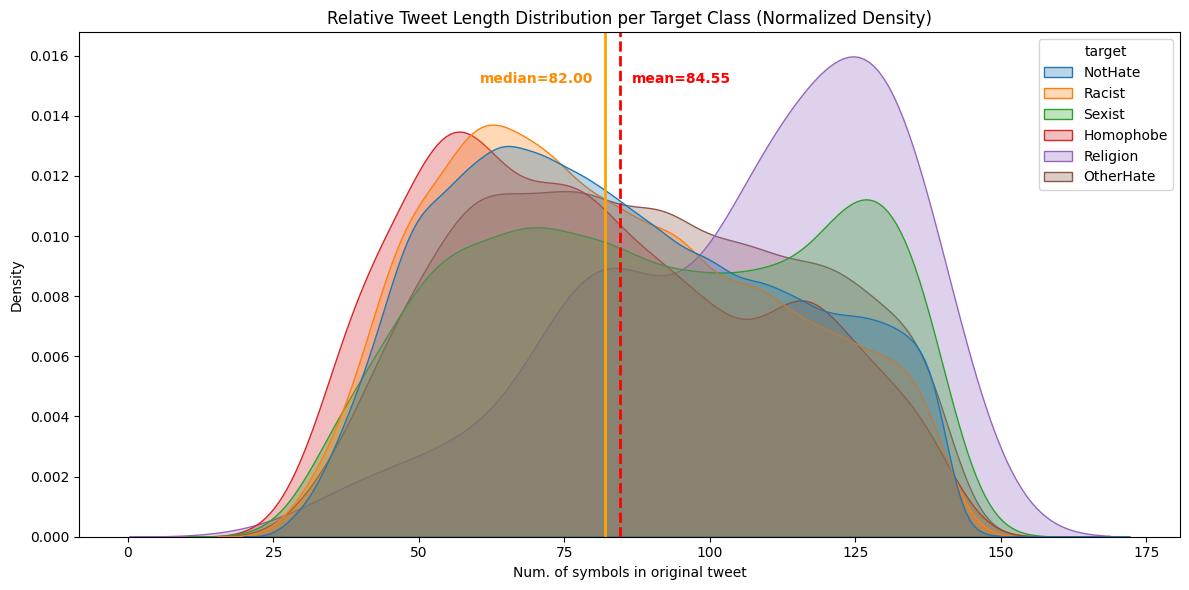

In [38]:
#Generate and capture the figure object
fig = plot_tweet_length_distribution(
    df=data_clean,
    x_col = 'num_symbols_origmsg',
    hue_col = 'target',
    target_mapping=labels_dict
)

#fig.savefig(os.path.join(drive_reports_dir, tweet_length_distribution.jpg), dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

Оцінка кількості символів у оригінальних повідомленнях показала чітку відмінність класу 4 - Religion від інших класів: повідомлення цього класу є зазвичай довшими ніж інші. Також відмінний бімодальний паттерн у порівнянні з іншими має клас 2 - Sexist, у якого приблизно половина повідомлень є довшими ніж зазвичай.

Враховуючи відмінності в патернах довжини повідомлень для різних класів, є сенс використати новостворену характеристику `num_symbols_origmsg`, що позначає довжину оригінального повідомлення в символах. У подальшому дану характеристику буде масштабовано.

## 3.Набори train, validation, test
Розділення даних на тренувальні, валідаційні та тестові вже задано авторами датасету - воно змінбватись не буде, щоб результати даної роботи за потреби можна було пізніше порівняти з іншими.

Визначимо тренуальний, валідаційний та тестовий набори:

In [20]:
split_ids = load_split_ids(zip_path=zip_path, split_dir='splits')

# Filter train, validation, test DataFrames
data_train = data_clean[data_clean['file_id'].astype(str).isin(split_ids['train'])]
data_val = data_clean[data_clean['file_id'].astype(str).isin(split_ids['val'])]
data_test = data_clean[data_clean['file_id'].astype(str).isin(split_ids['test'])]

In [40]:
print(f'Length of train set: {len(split_ids['train'])} ({round((len(split_ids['train'])*100)/len(data),0)}%)')
print(f'Length of validation set: {len(split_ids['val'])} ({round((len(split_ids['val'])*100)/len(data),0)}%)')
print(f'Length of test set: {len(split_ids['test'])} ({round((len(split_ids['test'])*100)/len(data),0)}%)')

Length of train set: 134823 (90.0%)
Length of validation set: 5000 (3.0%)
Length of test set: 10000 (7.0%)


In [22]:
# Define target labels
y_train = data_train['target']
y_val = data_val['target']
y_test = data_test['target']

Далі будемо розглядати тренувальні дані.

## 4.Перевірка пропущених значень у тренувальних даних

Перевіримо чи є у тренувальних даних пропущені значення:

In [23]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125502 entries, 1 to 149822
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   file_id      125502 non-null  object        
 1   img_url      125502 non-null  object        
 2   labels       125502 non-null  object        
 3   tweet_url    125502 non-null  object        
 4   tweet_text   125502 non-null  object        
 5   labels_str   125502 non-null  object        
 6   created_at   125502 non-null  datetime64[ns]
 7   img_text     125502 non-null  object        
 8   img_caption  125502 non-null  object        
 9   target       125502 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 10.5+ MB


На перший погляд пропущених значень у даних немає. Але у таблиці нижче видно, що, наприклад, текст з картинки `img_text` є не наявним для всіх повідомлень. Це пояснюється тим, що не всі такі картинки містять текст.

In [24]:
data_train.head(3)

,file_id,img_url,labels,tweet_url,tweet_text,labels_str,created_at,img_text,img_caption,target
1,1063020048816660480,http://pbs.twimg.com/ext_tw_video_thumb/1063019643709747200/pu/img/wK5HgoX6tFfxWJmi.jpg,"[5, 5, 5]",https://twitter.com/user/status/1063020048816660480,My horses are retarded https://t.co/HYhqc6d5WN,"[OtherHate, OtherHate, OtherHate]",2018-11-15 10:45:04.252,,a screenshot of a man in a snowy forest,5
2,1108927368075374593,http://pbs.twimg.com/media/D2OzhzHUwAADQjd.jpg,"[0, 0, 0]",https://twitter.com/user/status/1108927368075374593,“NIGGA ON MA MOMMA YOUNGBOY BE SPITTING REAL SHIT NIGGA” https://t.co/UczofqHrLq,"[NotHate, NotHate, NotHate]",2019-03-22 03:04:22.080,,a man getting his hair cut by a barber,0
3,1114558534635618305,http://pbs.twimg.com/ext_tw_video_thumb/1114018095348084738/pu/img/m6oP5fBm2RCcq5Wn.jpg,"[1, 0, 0]",https://twitter.com/user/status/1114558534635618305,RT xxSuGVNGxx: I ran into this HOLY NIGGA TODAY 😭😭😭😭 https://t.co/Wa6Spl9kIw,"[Racist, NotHate, NotHate]",2019-04-06 16:00:36.810,,a young man riding a skateboard down a sidewalk,0


## 5.Текстові ознаки у тренувальних даних

### Колонка `tweet_text`

У колонці `tweet_text` відсутніх значень немає - усі повідомлення містять текст:

In [44]:
# Check if some tweets have no text, i.e. tweets containing only a posted image
tweets_with_text = data_train[data_train['tweet_text'].notna() & (data_train['tweet_text'] != "") & (data_train['tweet_text'] != " ")]
print(f'Tweets with no text: {(data_train.shape[0] - tweets_with_text.shape[0])} of {data_train.shape[0]} - {round((data_train.shape[0] - tweets_with_text.shape[0])*100/(data_train.shape[0]),2)}%')

Tweets with no text: 0 of 125502 - 0.0%


### Колонка `img_text`

У більш як половини повідомлень відсутній `img_text` - текст на картинці:

In [45]:
# Check if some tweets have no text on its image
images_with_text = data_train[data_train['img_text'].notna() & (data_train['img_text'] != "") & (data_train['img_text'] != " ")]
print(f'Images with no text: {(data_train.shape[0] - images_with_text.shape[0])} of {data_train.shape[0]} - {round((data_train.shape[0] - images_with_text.shape[0])*100/(data_train.shape[0]),2)}%')

Images with no text: 76246 of 125502 - 60.75%


### Колонка `img_caption`
Для *всіх* повідомлень було згенеровано опис їх картинок:

In [46]:
# Check if some rows (observations) have no text from image: i.e. feature is NA, "", " "
images_with_caption = data_train[data_train['img_caption'].notna() & (data_train['img_caption'] != "") & (data_train['img_caption'] != " ")]
print(f'Images without captions: {(data_train.shape[0] - images_with_caption.shape[0])} of {data_train.shape[0]} - {round((data_train.shape[0] - images_with_caption.shape[0])*100/(data_train.shape[0]),2)}%')

Images without captions: 0 of 125502 - 0.0%


Підсумовуючи, дані для кожне повідомлення містять **три типи тексту**, для одного з яких у більш як половини відсутні значення. Це треба врахувати при подальшому препроцесигну даних - є сенс об'єднати тексти усіх трьох колонок у одне ціле. Тоді кожне з наявних повідомлень матиме нову агреговану характеристику, у колонці якої не буде міститись пропущених даних.

## 6.Дата та час `created_at` у тренувальних даних

Ця інформація може допомогти виявити event-driven особливості повідомлень.

Усі повідомлення мають дату та час їх створення:

In [47]:
# Check if some rows (observations) have no timestamps: i.e. feature is NA, "", " "
tweets_with_timestamp = data_train[data_train['created_at'].notna() & (data_train['created_at'] != "") & (data_train['created_at'] != " ")]
print(f'Tweets with no timestamp: {(data_train.shape[0] - tweets_with_timestamp.shape[0])} of {data_train.shape[0]} - {round((data_train.shape[0] - tweets_with_timestamp.shape[0])*100/(data_train.shape[0]),2)}%')

Tweets with no timestamp: 0 of 125502 - 0.0%


In [48]:
data_train.head(3)

,file_id,img_url,labels,tweet_url,tweet_text,labels_str,created_at,img_text,img_caption,target,num_symbols_origmsg
1,1063020048816660480,http://pbs.twimg.com/ext_tw_video_thumb/1063019643709747200/pu/img/wK5HgoX6tFfxWJmi.jpg,"[5, 5, 5]",https://twitter.com/user/status/1063020048816660480,My horses are retarded https://t.co/HYhqc6d5WN,"[OtherHate, OtherHate, OtherHate]",2018-11-15 10:45:04.252,,a screenshot of a man in a snowy forest,5,46
2,1108927368075374593,http://pbs.twimg.com/media/D2OzhzHUwAADQjd.jpg,"[0, 0, 0]",https://twitter.com/user/status/1108927368075374593,“NIGGA ON MA MOMMA YOUNGBOY BE SPITTING REAL SHIT NIGGA” https://t.co/UczofqHrLq,"[NotHate, NotHate, NotHate]",2019-03-22 03:04:22.080,,a man getting his hair cut by a barber,0,80
3,1114558534635618305,http://pbs.twimg.com/ext_tw_video_thumb/1114018095348084738/pu/img/m6oP5fBm2RCcq5Wn.jpg,"[1, 0, 0]",https://twitter.com/user/status/1114558534635618305,RT xxSuGVNGxx: I ran into this HOLY NIGGA TODAY 😭😭😭😭 https://t.co/Wa6Spl9kIw,"[Racist, NotHate, NotHate]",2019-04-06 16:00:36.810,,a young man riding a skateboard down a sidewalk,0,76


Далі дослідимо дату створення повідомлення. Розглянемо кількість повідомлень, що наявні у тренувальних даних, поденно.

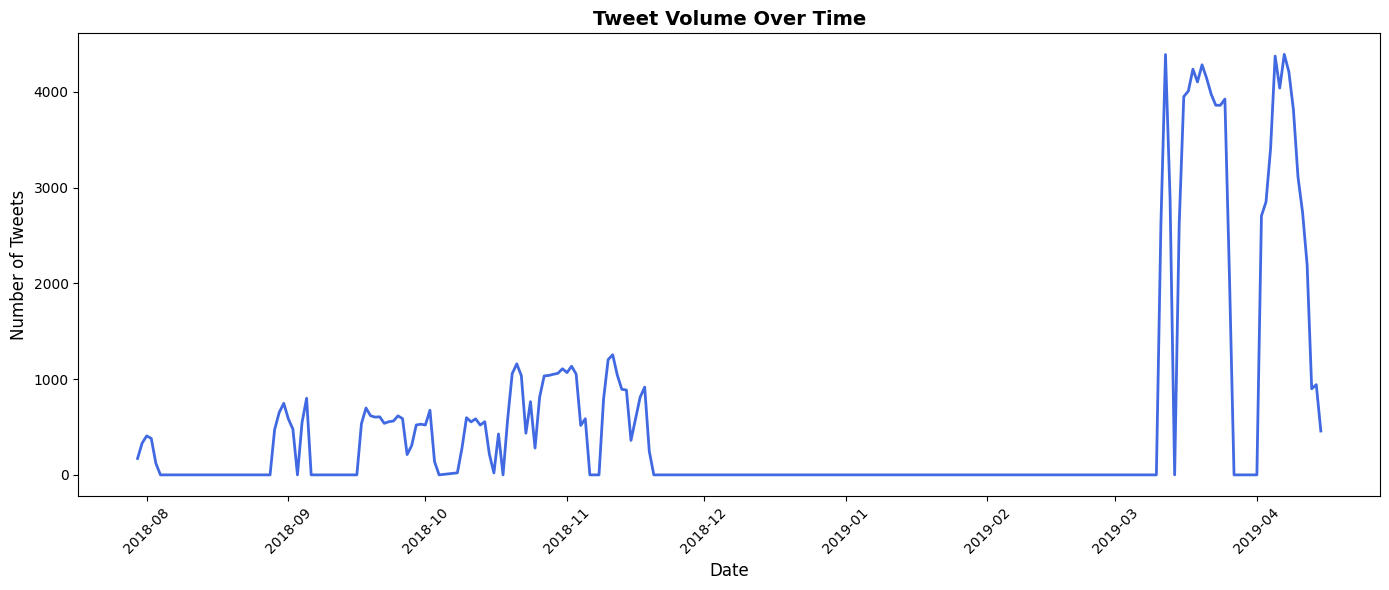

In [49]:
# Plot tweet number over investigated time
fig = plot_tweet_volume_over_time(
    df=data_clean,
    resample_freq='D'
)
#fig.savefig(os.path.join(drive_reports_dir, 'tweet_volumne_over_time.jpg'), dpi=300, bbox_inches='tight', facecolor='white')
fig.show()

З графіка видно, що повідомлення, принаймні з тренувального набору, були зібрані не рівномірно по днях: збір даних проводився у вибрані дні і з різним об'ємом, можливо, було встановлено кастомний фільтр на повідомлення.

Якщо дослідити частку твітів кожного з цільових класів (графік нижче) у розрізі доби (24 год.), то видно, що частки повідомлень класів 1 - Racist та 2 - Sexist мають деякі коливання протягом доби. Наприклад, приблизно зранку і до обіду частка расистьских повідомлень зазвичай найменшою протягом доби, а для сексистських повідомлень навпаки - найбільшою.  

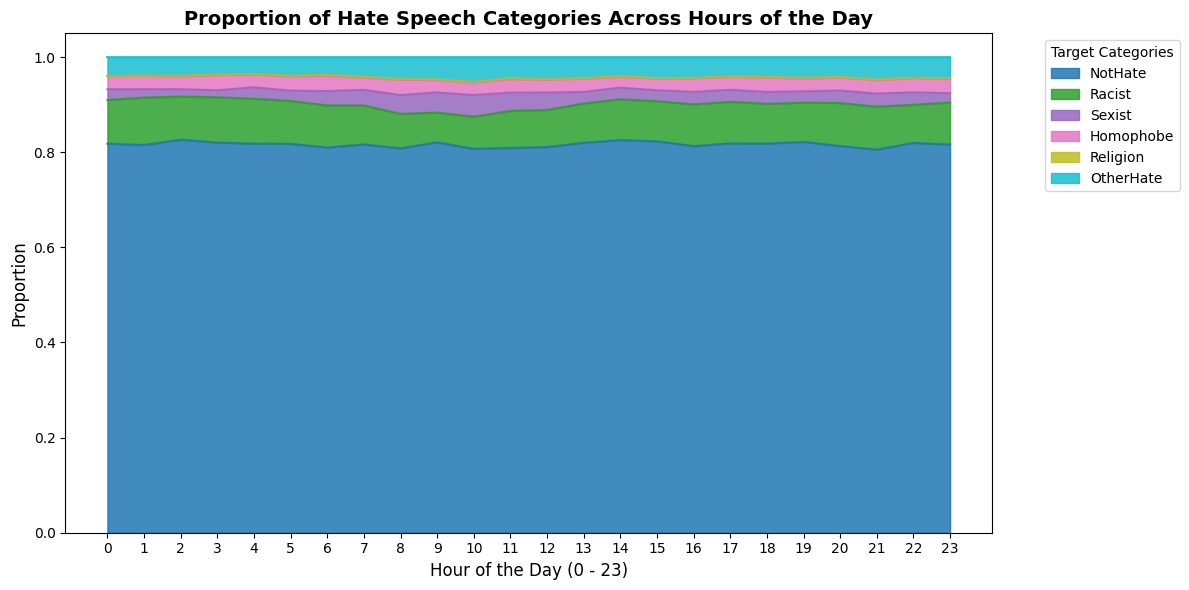

In [50]:
# Plot target category proportion accross hours of the day
fig = plot_hate_speech_proportions(
    df=data_clean,
    time_dimension='hour',
    target_mapping=labels_dict
)

fig.savefig(os.path.join(drive_reports_dir, 'tweet_proportions_by_dayhour.jpg'), dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

Як видно на графіку нижче, у залежності від дня тижня частки повідомлень зазвичай сталі або мають зовсім незначні коливання.

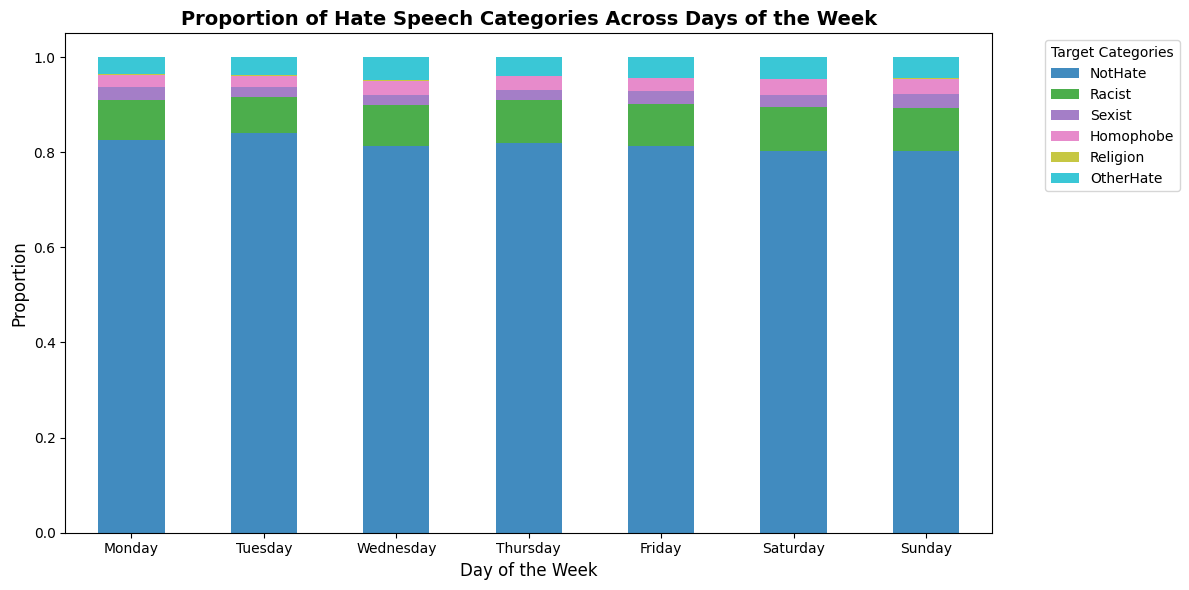

In [51]:
# Plot target category proportion accross days of the week
fig = plot_hate_speech_proportions(
    df=data_clean,
    time_dimension='day',
    target_mapping=labels_dict
)

#fig.savefig(os.path.join(drive_reports_dir, 'tweet_proportion_by_weekday.jpg'), dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

Загалом, дату та час можна використати для feature engineering, наприклад, для відстеження циклічних паттернів за часом доби, днем тижня (вихідні чи будні). Такі додаткові ознаки будуть додані до даниз на етапі препроцессингу.

## **Висновки**
- оцінки експертів з `labels` було агреговано для визначення однозначної (однієї) категорії цільової змінної для спостережень;
- створено нову ознаку `num_symbols_original`, що позначає довжину оригінального тексту твіттер-повідомлення у символах;
- `tweet_text`, `img_text` та `img_caption` буде об'єднано у одну характеристику
- дату та час `created_at` буде перетворено на додаткові ознаки визначення часу доби, дня тижня.

In [1]:
# Save data to Google Drive
data_clean.to_parquet(os.path.join(drive_data_dir, 'twitter_data_after_eda.parquet'))
data_train.to_parquet(os.path.join(drive_data_dir, 'train.parquet'))
data_val.to_parquet(os.path.join(drive_data_dir, 'val.parquet'))
data_test.to_parquet(os.path.join(drive_data_dir, 'test.parquet'))
y_train.to_frame().to_parquet(os.path.join(drive_data_dir, 'y_train.parquet'))
y_val.to_frame().to_parquet(os.path.join(drive_data_dir, 'y_val.parquet'))
y_test.to_frame().to_parquet(os.path.join(drive_data_dir, 'y_test.parquet'))